In [1]:
# Repo-root bootstrap: find the directory containing the `llm_perf` package
# (walking up from CWD) and chdir there so paths like "llm_perf/database/..."
# and "assets/..." resolve regardless of where the notebook lives on disk.
import os
from pathlib import Path
_p = Path.cwd()
while not (_p / "llm_perf" / "__init__.py").exists():
    if _p == _p.parent:
        raise RuntimeError("Could not find llm_perf repo root from " + str(Path.cwd()))
    _p = _p.parent
os.chdir(_p)
print("cwd:", Path.cwd())

cwd: /Users/jasonlu/Projects/ai.cluster/llm_perf


# Basic Pareto Sweep — the Full Exploration Space

**Question:** where does the (throughput/GPU, interactivity) Pareto frontier come from? What does the underlying point cloud look like — i.e. what's the full space of `(PP, TP, EP, SP, B)` choices that the frontier selects from?

The other Pareto notebooks (`pareto_vs_io`, `pareto_vs_mem`, `pareto_vs_overhead`) only plot the frontier — the upper-right envelope of this cloud. This notebook shows the cloud itself so the frontier-extraction step is visible.

**Setup:** GPT-1.8T MoE @ FP4 on GB200 NVL72 (baseline hardware, no I/O / HBM / overhead sweeps). Enumerate every valid `(PP, TP, EP, SP)` partition, sweep batch `B` from 1 up to the KV-paging max, score each `(partition, B)` evaluation, then extract the upper-right envelope.

**What's on the plot:**

- **Gray cloud** — every valid `(partition, B)` evaluation in the exploration space.
- **Colored points** — the same cloud, but colored by partition PP (so you can see which shape dominates which region).
- **Bold line + markers** — the extracted Pareto frontier (upper-right envelope).
- **Annotations** — winning `(PP, TP, EP, B)` at a few frontier corners.

The ratio `|frontier| / |cloud|` quantifies how much of the search space is actually useful — most `(partition, B)` evaluations are dominated.

## 1. Imports and spec loading

In [2]:
from __future__ import annotations

import math
from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt

from llm_perf import InferenceCalculator
from llm_perf.core.kv_paging_model import KVPagingConfig, compute_kv_paging
from llm_perf.core.memory_model import compute_memory
from llm_perf.io import load_model_spec, load_system_spec, load_tuning_spec
from llm_perf.specs.partition_spec import PartitionSpec
from llm_perf.specs.system_spec import span_tiers

MODEL = "llm_perf/database/model/gpt_1_8t_moe.json"
SYSTEM = "llm_perf/database/system/gb200.72gpu.json"
TUNER = "llm_perf/database/tuner/gpt_1_8t_moe.tuner.json"

S_DECODE = 8192
BPP_FP4 = 0.5

model = load_model_spec(MODEL)
model.bytes_per_param = BPP_FP4
system = load_system_spec(SYSTEM)
tuner_base = load_tuning_spec(TUNER)
tuner_base.S_decode = S_DECODE
tuner_base.B_decode = 1

up_alpha, up_bw, _ = span_tiers(system.get_tier_chain('TP'), 2)
print(f"Model: {model.name}  L={model.L}  H={model.H}  n_kv={model.n_kv}  b={model.bytes_per_param}")
print(f"System: {system.num_devices} GPUs  HBM={system.device.hbm_bandwidth_GBps:.0f} GB/s  "
      f"peak={system.device.peak_flops_TF:.0f} TF  "
      f"scale-up={up_bw:.0f} GB/s · {up_alpha:.2f} μs")

Model: GPT-1.8T-MoE  L=120  H=20480  n_kv=16  b=0.5
System: 72 GPUs  HBM=8000 GB/s  peak=2250 TF  scale-up=900 GB/s · 0.50 μs


## 2. Partition enumeration

Constraints (from `llm_perf/utils/partition_enum.py` — `describe_constraints` printed below):

- **`PP ≤ 8`** — applied here as an operational cap (see note below). The unbounded `pp_max` default is 32; this notebook pins `pp_max=8` to match the typical PP-capped operational regime where pipeline bubble cost / latency budget / microbatch floor make deeper PP impractical. PP is chosen from a ladder `[1, 2, 3, 4, 5, 6, 8]` under this cap (no divisibility into `L`).
- `TP ≤ min(n_kv, n_experts)` so each TP rank holds ≥ 1 KV head and ≤ all-expert reach (powers-of-2 ladder).
- `EP ≤ n_experts` (powers-of-2 ladder); `EP = 1` for dense models.
- `TP · EP ≤ scale_up_domain` so the heavy intra-layer collectives stay inside the rack-local NVLink / NVL boundary (NVL72 → 72 ranks at tier 0).
- `SP` sweeps the ladder `[1, 2, 4, 8, 16, 32, 64]`.
- `PP · TP · EP · SP ≤ num_devices` (the cluster-fit cap).

For GPT-1.8T MoE on NVL72: `L = 120`, `n_kv = 16`, `n_experts = 16`, `scale_up = 72` (single-tier NVL fabric). With the PP=8 cap, each PP stage owns `L/PP = 15` layers — substantially heavier per-stage workload than the unbounded case (`L/PP = 3.75` at PP=32).

> **Why the cap?** Deep PP (e.g., PP=32) maximizes weight amortization but requires very large microbatch counts to keep the pipeline full (`B ≥ PP` to avoid bubble), and `t_LM` plus inter-stage P2P transit costs grow with PP. Operational deployments often cap PP at 8–16 to bound the bubble-vs-batch tradeoff and the kernel-launch budget per stage. To compare against the deeper-PP frontier, change `PP_MAX` in §1 / re-run.


In [3]:
PP_MAX = 8   # Operational cap; raise to 32 to match unbounded-PP analysis.

from llm_perf.utils import (
    enumerate_partitions as _enumerate_partitions,
    describe_constraints,
)


def enumerate_partitions(num_devices: int) -> list[PartitionSpec]:
    """Local shim around llm_perf.utils.enumerate_partitions; pins (model, system, pp_max).

    Constraints applied: PP <= PP_MAX (set above; default 8 here, vs the
    library's 32);  TP <= min(n_kv, n_experts); EP <= n_experts (or 1 for
    dense); TP*EP <= scale_up_domain_size(system); SP <= 64 (ladder-based);
    PP*TP*EP*SP <= num_devices.
    See `llm_perf/utils/partition_enum.py` for the full derivation.
    """
    return _enumerate_partitions(model, system, num_devices=num_devices, pp_max=PP_MAX)


print(describe_constraints(model, system, pp_max=PP_MAX))

partitions = enumerate_partitions(system.num_devices)
print(f"Valid partitions: {len(partitions)}")
print("First 10:", [f"PP={p.PP} TP={p.TP} EP={p.EP} SP={p.SP}" for p in partitions[:10]])


PP ≤ 8; TP ≤ min(n_kv=16, n_experts=16) = 16; EP ≤ n_experts=16; TP·EP ≤ scale_up=72 (tier_idx=0)
Valid partitions: 260
First 10: ['PP=1 TP=1 EP=1 SP=1', 'PP=1 TP=1 EP=1 SP=2', 'PP=1 TP=1 EP=1 SP=4', 'PP=1 TP=1 EP=1 SP=8', 'PP=1 TP=1 EP=1 SP=16', 'PP=1 TP=1 EP=1 SP=32', 'PP=1 TP=1 EP=1 SP=64', 'PP=1 TP=1 EP=2 SP=1', 'PP=1 TP=1 EP=2 SP=2', 'PP=1 TP=1 EP=2 SP=4']


## 3. Sweep every `(partition, B)` in the exploration space

For each partition we derive `B_max` from the KV paging model (how many concurrent sequences fit in HBM after weights), then sweep log-spaced batch sizes from 1 to `B_max`. Each evaluation produces a point in (tput/GPU, 1/TPOT) space.

In [4]:
@dataclass
class Point:
    partition: PartitionSpec
    B: int
    tput_per_gpu: float
    interactivity: float
    TPOT_ms: float

    @property
    def part_label(self) -> str:
        p = self.partition
        return f"PP={p.PP} TP={p.TP} EP={p.EP} SP={p.SP}"


def log_spaced_batch_sizes(b_max: int) -> list[int]:
    if b_max <= 1:
        return [1]
    n = max(int(math.log10(b_max) * 10), 16)
    raw = {1, b_max}
    for i in range(n + 1):
        raw.add(max(1, int(round(10 ** (i * math.log10(b_max) / n)))))
    p = 1
    while p <= b_max:
        raw.add(p)
        p *= 2
    return sorted(raw)


def sweep_partition(partition: PartitionSpec) -> list[Point]:
    try:
        mem = compute_memory(model, system, partition, tuner_base)
    except Exception:
        return []
    paging = KVPagingConfig(block_size=16, beam_width=1, system_overhead_GB=1.5)
    kv = compute_kv_paging(model, system, partition, tuner_base, mem, paging)
    b_max = int(kv.max_sequences)
    if b_max < 1:
        return []
    pts: list[Point] = []
    for B in log_spaced_batch_sizes(b_max):
        tuner = deepcopy(tuner_base)
        tuner.B_decode = B
        try:
            r = InferenceCalculator(model, system, partition, tuner).run()
        except Exception:
            continue
        if r.latency.TPOT <= 0:
            continue
        pts.append(Point(
            partition=partition,
            B=B,
            tput_per_gpu=r.latency.TTPS / system.num_devices,
            interactivity=1.0 / r.latency.TPOT,
            TPOT_ms=r.latency.TPOT * 1e3,
        ))
    return pts


all_points: list[Point] = []
for part in partitions:
    all_points.extend(sweep_partition(part))

print(f"Total evaluations in the exploration space: {len(all_points)}")
print(f"Distinct partitions with ≥1 feasible B: "
      f"{len({p.part_label for p in all_points})}")

Total evaluations in the exploration space: 5895
Distinct partitions with ≥1 feasible B: 200


## 4. Extract the Pareto frontier

Walk the points in order of decreasing throughput/GPU and keep those that strictly improve interactivity — the upper-right envelope.

In [5]:
def pareto_frontier(points: list[Point]) -> list[Point]:
    sorted_pts = sorted(points, key=lambda p: (-p.tput_per_gpu, -p.interactivity))
    frontier: list[Point] = []
    best_interact = -math.inf
    for p in sorted_pts:
        if p.interactivity > best_interact + 1e-9:
            frontier.append(p)
            best_interact = p.interactivity
    frontier.sort(key=lambda p: p.tput_per_gpu)
    return frontier


frontier = pareto_frontier(all_points)
print(f"Frontier points: {len(frontier)}  ({len(frontier)/len(all_points)*100:.1f}% of cloud)")

# Winner summary
winners: dict[str, int] = {}
for p in frontier:
    winners[p.part_label] = winners.get(p.part_label, 0) + 1
print("\nPartitions appearing on the frontier (count of corner points):")
for k, v in sorted(winners.items(), key=lambda kv: -kv[1]):
    print(f"  {k:30s}  ×{v}")

Frontier points: 37  (0.6% of cloud)

Partitions appearing on the frontier (count of corner points):
  PP=8 TP=8 EP=1 SP=1             ×33
  PP=6 TP=4 EP=1 SP=1             ×4


## 5. Plot: exploration space + frontier

Two panels side by side:
- **Left:** raw cloud in gray with the frontier overlaid — visualize how small a fraction of the space the frontier occupies.
- **Right:** same cloud, but colored by PP — reveals which partition shape dominates which region of the space.

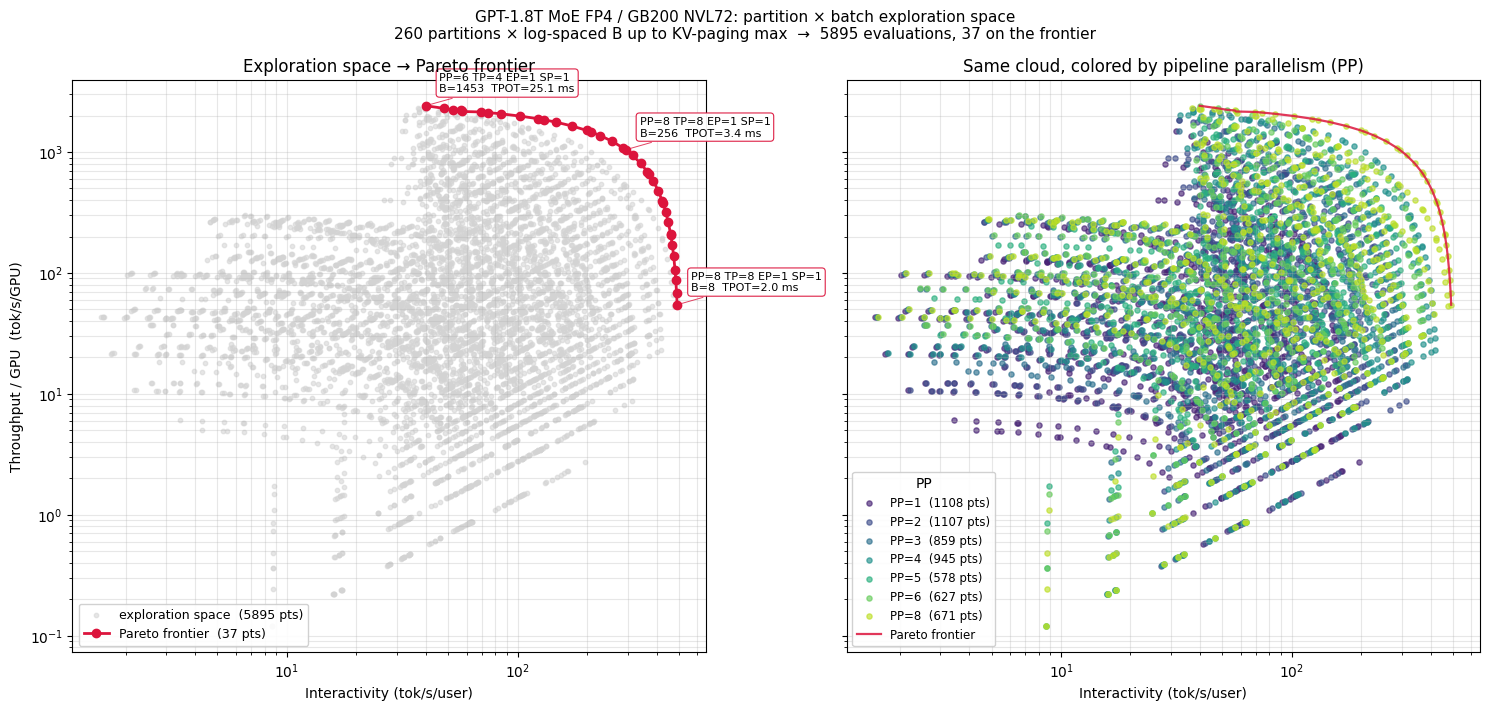

In [6]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 7.2), sharex=True, sharey=True)

xs_all = [p.interactivity for p in all_points]
ys_all = [p.tput_per_gpu for p in all_points]
xs_fr = [p.interactivity for p in frontier]
ys_fr = [p.tput_per_gpu for p in frontier]

# --- Left panel: cloud + frontier ---
axL.scatter(xs_all, ys_all, s=10, color="lightgray", alpha=0.55,
            label=f"exploration space  ({len(all_points)} pts)")
axL.plot(xs_fr, ys_fr, "-o", color="crimson", lw=2.0, ms=6,
         label=f"Pareto frontier  ({len(frontier)} pts)")

# Annotate a handful of frontier corners (evenly spaced along the frontier).
if len(frontier) >= 3:
    idxs = [0, len(frontier) // 2, len(frontier) - 1]
else:
    idxs = list(range(len(frontier)))
for i in idxs:
    p = frontier[i]
    axL.annotate(
        f"{p.part_label}\nB={p.B}  TPOT={p.TPOT_ms:.1f} ms",
        xy=(p.interactivity, p.tput_per_gpu),
        xytext=(10, 10), textcoords="offset points",
        fontsize=8, ha="left", color="black",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="crimson", alpha=0.95, lw=0.8),
        arrowprops=dict(arrowstyle="-", color="crimson", lw=0.7, alpha=0.8),
    )

axL.set_xscale("log")
axL.set_yscale("log")
axL.set_xlabel("Interactivity (tok/s/user)")
axL.set_ylabel("Throughput / GPU  (tok/s/GPU)")
axL.set_title("Exploration space → Pareto frontier")
axL.grid(True, which="both", alpha=0.3)
axL.legend(loc="lower left", fontsize=9, framealpha=0.9)

# --- Right panel: colored by PP ---
pps_sorted = sorted({p.partition.PP for p in all_points})
cmap = plt.get_cmap("viridis")
pp_colors = {pp: cmap(0.1 + 0.8 * i / max(1, len(pps_sorted) - 1))
             for i, pp in enumerate(pps_sorted)}

for pp in pps_sorted:
    sub = [p for p in all_points if p.partition.PP == pp]
    axR.scatter([p.interactivity for p in sub],
                [p.tput_per_gpu for p in sub],
                s=14, color=pp_colors[pp], alpha=0.65,
                label=f"PP={pp}  ({len(sub)} pts)")
axR.plot(xs_fr, ys_fr, "-", color="crimson", lw=1.6, alpha=0.85,
         label="Pareto frontier")

axR.set_xlabel("Interactivity (tok/s/user)")
axR.set_title("Same cloud, colored by pipeline parallelism (PP)")
axR.grid(True, which="both", alpha=0.3)
axR.legend(loc="lower left", fontsize=8.5, framealpha=0.9, title="PP")

fig.suptitle(
    f"GPT-1.8T MoE FP4 / GB200 NVL72: partition × batch exploration space\n"
    f"{len(partitions)} partitions × log-spaced B up to KV-paging max  →  "
    f"{len(all_points)} evaluations, {len(frontier)} on the frontier",
    fontsize=11,
)
fig.tight_layout()
fig.savefig("assets/pareto_basic.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. Takeaways

- **The frontier is a small slice of the space.** Only a handful of the hundreds of `(partition, B)` evaluations sit on the envelope — most configurations are strictly dominated in both throughput/GPU and interactivity. Under the `PP ≤ 8` cap, the frontier is overwhelmingly `PP=8 TP=8 EP=1 SP=1` (33 of 37 corners) with a few `PP=6 TP=4 EP=1 SP=1` rounding out the high-interactivity corner.
- **PP dominates regime selection — even under the cap.** Coloring by PP on the right panel makes the segmentation obvious: shallow PP (1–4) lives in the high-interactivity corner (low per-GPU throughput, small B), deep PP (6–8) in the high-throughput corner (large B amortizes weight reads more effectively per device). Raising `PP_MAX` to 32 (the library default) would push the frontier outward and shift the dominant winner toward `PP=32 TP=2` shapes — see `pareto_vs_io` ideal-IO reference for that limit.
- **Within a partition, B traces a curve.** Fixing `(PP, TP, EP, SP)` and sweeping B gives a monotone arc — tput/GPU rises with B (weight reads amortize), interactivity falls (longer token time). Partitions differ in *where* those arcs sit, and the frontier picks the outer hull.
- **Why it matters for the other notebooks.** `pareto_vs_io`, `pareto_vs_mem`, and `pareto_vs_overhead` each re-run this exact enumeration once per hardware/overhead anchor, then plot only the frontier per anchor. The shifts between frontiers in those studies are shifts of this cloud — individual points moving in (tput, 1/TPOT) as the hardware changes.
- **What to swap.** Change `MODEL`/`SYSTEM`/`TUNER` in §1 to study a different model/system pair. Adjust `PP_MAX` in §2 to relax or tighten the PP cap — the constraint logic in `llm_perf/utils/partition_enum.py` reads `n_kv` / `n_experts` / `scale_up_domain` directly from the model and system, so no other per-notebook overrides are needed for a different fixture.


## 7. Kernel-launch overhead: frontier comparison

The default tuner ships `kernel_launch_us = 1.5 μs` (CUDA-Graphs-replayed serving — `decode.md §7.1`). Setting it to 0 zeroes the per-microbatch SW dispatch budget `t_SW` and recovers the legacy GPU-only roofline.

We extract the frontier under both settings and overlay them. Where the two diverge, the GPU bottleneck has shrunk below the per-microbatch launch budget — typically the high-interactivity (small-B, deep-PP) corner where each microbatch's GPU work is small.


Kernel-on frontier:  37 pts
Kernel-off frontier: 37 pts


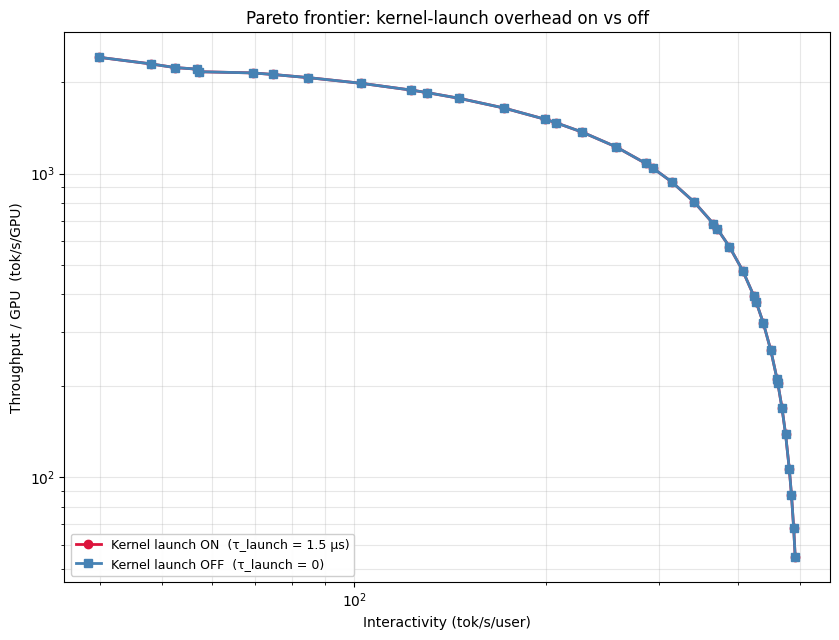

In [7]:
import pandas as pd


def sweep_with_breakdown(tuner_template):
    """Same enumeration as §3 but stores the full LatencyResults breakdown
    on each point so we can build the table in §8 without re-running."""
    rows = []
    for part in partitions:
        try:
            mem = compute_memory(model, system, part, tuner_template)
        except Exception:
            continue
        paging = KVPagingConfig(block_size=16, beam_width=1, system_overhead_GB=1.5)
        kv = compute_kv_paging(model, system, part, tuner_template, mem, paging)
        b_max = int(kv.max_sequences)
        if b_max < 1:
            continue
        for B in log_spaced_batch_sizes(b_max):
            tuner = deepcopy(tuner_template)
            tuner.B_decode = B
            try:
                r = InferenceCalculator(model, system, part, tuner).run()
            except Exception:
                continue
            lat = r.latency
            if lat.TPOT <= 0:
                continue
            rows.append({
                "PP": part.PP, "TP": part.TP, "EP": part.EP, "SP": part.SP, "B": B,
                "tput_per_gpu": lat.TTPS / system.num_devices,
                "interactivity": 1.0 / lat.TPOT,
                "TPOT_ms": lat.TPOT * 1e3,
                "t_compute_us": lat.t_compute * 1e6,
                "t_mem_us": lat.t_mem * 1e6,
                "t_local_us": lat.t_local * 1e6,
                "t_comm_us": lat.t_comm * 1e6,
                "t_stage_us": lat.t_stage * 1e6,
                "t_SW_us": lat.t_SW * 1e6,
                "t_LM_us": lat.t_LM * 1e6,
                "gamma_pp": lat.pp_bubble_factor,
            })
    return rows


def frontier_rows(rows):
    """Same upper-right envelope walk as §4 but on dict rows."""
    srt = sorted(rows, key=lambda r: (-r["tput_per_gpu"], -r["interactivity"]))
    fr, best = [], -math.inf
    for r in srt:
        if r["interactivity"] > best + 1e-9:
            fr.append(r)
            best = r["interactivity"]
    fr.sort(key=lambda r: r["tput_per_gpu"])
    return fr


# Kernel-launch ON (default tuner — τ_launch = 1.5 μs)
rows_on = sweep_with_breakdown(deepcopy(tuner_base))
frontier_on = frontier_rows(rows_on)

# Kernel-launch OFF (τ_launch = 0 → t_SW = 0; legacy GPU-only roofline)
tuner_off = deepcopy(tuner_base)
tuner_off.kernel_launch_us = 0.0
rows_off = sweep_with_breakdown(tuner_off)
frontier_off = frontier_rows(rows_off)

print(f"Kernel-on frontier:  {len(frontier_on)} pts")
print(f"Kernel-off frontier: {len(frontier_off)} pts")

# Plot the two frontiers overlaid
fig, ax = plt.subplots(figsize=(8.5, 6.5))
ax.plot([r["interactivity"] for r in frontier_on], [r["tput_per_gpu"] for r in frontier_on],
        "-o", color="crimson", lw=2.0, ms=6,
        label=f"Kernel launch ON  (τ_launch = {tuner_base.kernel_launch_us:.1f} μs)")
ax.plot([r["interactivity"] for r in frontier_off], [r["tput_per_gpu"] for r in frontier_off],
        "-s", color="steelblue", lw=2.0, ms=6,
        label="Kernel launch OFF  (τ_launch = 0)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Interactivity (tok/s/user)")
ax.set_ylabel("Throughput / GPU  (tok/s/GPU)")
ax.set_title("Pareto frontier: kernel-launch overhead on vs off")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower left", fontsize=9, framealpha=0.95)
plt.tight_layout()
plt.savefig("assets/pareto_basic_kernel_toggle.png", dpi=120, bbox_inches="tight")
plt.show()


## 8. Per-frontier-point latency breakdown

For each kernel-on frontier point, decompose the per-step time into the contributions defined in `decode.md §6.2 / §7.2`:

- `t_compute` — `B · F_token,device / R_GPU` (compute roofline, §6.2)
- `t_mem` — `Σ_i (T_θ,i + B · T_KV,i) / BW_eff,i` (multi-tier memory roofline, §6.2)
- `t_local = max(t_compute, t_mem)` — per-stage GPU roofline floor
- `t_comm` — overlap-aware collective communication (§5.5)
- `t_stage = t_local + max(0, t_comm − ρ · t_local)` — GPU-only per-stage step time (§6.2)
- `t_SW` — per-microbatch CPU/dispatch budget (§7.1); zero in the kernel-off case
- `t_LM` — once-per-step LM head H→V projection on stage PP-1 (§6.2)
- `γ_pp = max(1, PP/B)` — pipeline bubble multiplier (§7.2)

The user-observed step time is `t_step,user = γ_pp · [t_stage + max(0, t_SW − ρ_SW · t_stage)] + t_LM`. All time columns are in microseconds.


In [8]:
df = pd.DataFrame(frontier_on)
cols = ["PP", "TP", "EP", "SP", "B",
        "tput_per_gpu", "TPOT_ms",
        "t_compute_us", "t_mem_us", "t_local_us",
        "t_comm_us", "t_stage_us",
        "t_SW_us", "t_LM_us", "gamma_pp"]
df = df[cols].sort_values("tput_per_gpu").reset_index(drop=True)

# Round for display
df_disp = df.copy()
for c in df_disp.columns:
    if c in ("PP", "TP", "EP", "SP", "B"):
        continue
    if c == "gamma_pp":
        df_disp[c] = df_disp[c].round(2)
    elif c == "TPOT_ms":
        df_disp[c] = df_disp[c].round(2)
    elif c == "tput_per_gpu":
        df_disp[c] = df_disp[c].round(1)
    else:
        df_disp[c] = df_disp[c].round(1)

df_disp


,PP,TP,EP,SP,B,tput_per_gpu,TPOT_ms,t_compute_us,t_mem_us,t_local_us,t_comm_us,t_stage_us,t_SW_us,t_LM_us,gamma_pp
0,8,8,1,1,8,54.5,2.04,10.1,1801.4,1801.4,215.3,2016.7,318.0,20.6,1.0
1,8,8,1,1,10,67.8,2.05,12.7,1811.3,1811.3,216.5,2027.7,318.0,20.6,1.0
2,8,8,1,1,13,87.4,2.06,16.5,1826.0,1826.0,218.3,2044.3,318.0,20.6,1.0
3,8,8,1,1,16,106.8,2.08,20.3,1840.7,1840.7,220.1,2060.8,318.0,20.6,1.0
4,8,8,1,1,21,138.3,2.11,26.6,1865.3,1865.3,223.1,2088.4,318.0,20.7,1.0
5,8,8,1,1,26,169.0,2.14,33.0,1889.9,1889.9,226.1,2116.0,318.0,20.7,1.0
6,8,8,1,1,32,204.8,2.17,40.6,1919.4,1919.4,229.7,2149.0,318.0,20.8,1.0
7,8,8,1,1,33,210.7,2.18,41.8,1924.3,1924.3,230.3,2154.6,318.0,20.8,1.0
8,8,8,1,1,42,262.2,2.23,53.3,1968.5,1968.5,235.6,2204.2,318.0,20.9,1.0
9,8,8,1,1,53,322.0,2.29,67.2,2022.6,2022.6,242.2,2264.8,318.0,20.9,1.0
